# Logistic Regression

### Credits: https://www.kdnuggets.com/2022/04/logistic-regression-classification.html

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from math import exp
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
data = pd.read_csv("Social_Network_Ads.csv")
data.head(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


### Train-Test Split

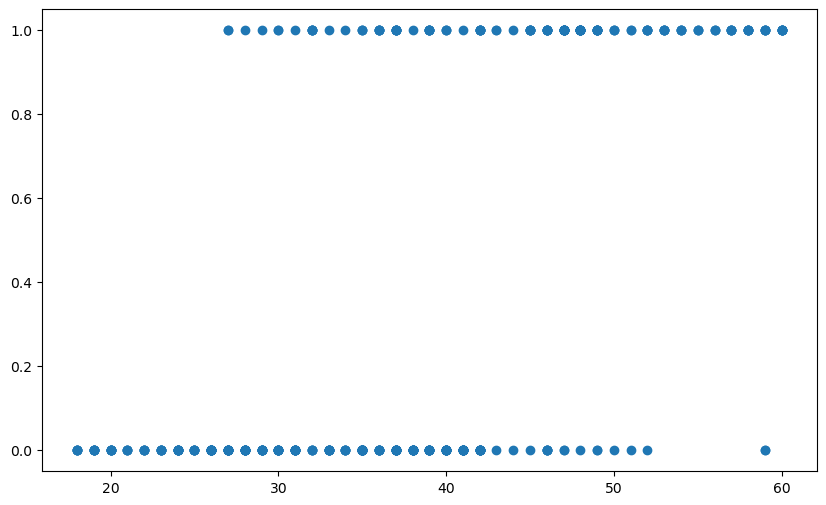

In [3]:
# Visualizing the dataset by Age and Purchased
plt.scatter(data['Age'], data['Purchased'])
plt.show()# Divide the Data into training set and test set
X_train, X_test, y_train, y_test = train_test_split(data['Age'], data['Purchased'], test_size=0.20)

### Logistic Regression

<p> We need to standardize the data and shift the mean to the origin to obtain accurate results, given the nature of the Logistic Equation. Next, we'll implement a method to make predictions, which will return probabilities. After this, we can proceed to training the model. The training process will last for 300 epochs, during which the partial derivatives are calculated and the weights are updated at each epoch. </p>

In [6]:
# Building the Logistic Regression model

# Standardising the data
def normalize(X):
  return X - X.mean()

# Make predictions
def predict(X, b0, b1):
  return np.array([1 / (1 + exp(-1*b0 + -1*b1*x)) for x in X])

# The model
def logistic_regression(X, Y):

   X = normalize(X)

   # Initializing variables
   b0 = 0
   b1 = 0
   L = 0.001
   epochs = 300

   for epoch in range(epochs):
      y_pred = predict(X, b0, b1)
      D_b0 = -2 * sum((Y - y_pred) * y_pred * (1 - y_pred)) # Loss wrt b0
      D_b1 = -2 * sum(X * (Y - y_pred) * y_pred * (1 - y_pred)) # Loss wrt b1
      # Update b0 and b1
      b0 = b0 - L * D_b0
      b1 = b1 - L * D_b1

      return b0, b1

### Model Training

<p> As previously stated, the prediction equation will output a probability. Since this is a classification task, we need to convert these probabilities into binary values. To do so, we select a threshold. In this example, we’ll use 0.5, meaning any predicted value above 0.5 will be classified as 1, while values below 0.5 will be classified as 0.

To measure accuracy, we can calculate the number of correct predictions and divide it by the total number of test cases. </p>

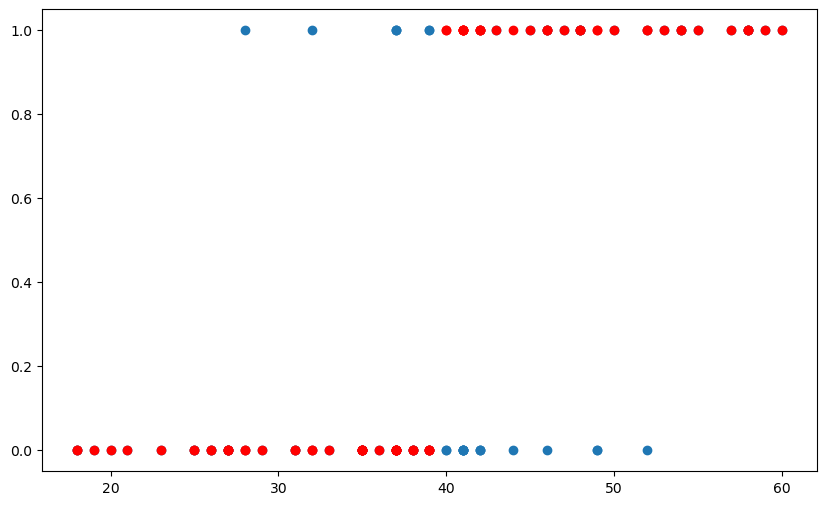

Accuracy = 0.0125
Accuracy = 0.025
Accuracy = 0.0375
Accuracy = 0.05
Accuracy = 0.0625
Accuracy = 0.075
Accuracy = 0.0875
Accuracy = 0.1
Accuracy = 0.1125
Accuracy = 0.125
Accuracy = 0.1375
Accuracy = 0.15
Accuracy = 0.1625
Accuracy = 0.175
Accuracy = 0.1875
Accuracy = 0.2
Accuracy = 0.2125
Accuracy = 0.225
Accuracy = 0.2375
Accuracy = 0.25
Accuracy = 0.2625
Accuracy = 0.275
Accuracy = 0.2875
Accuracy = 0.3
Accuracy = 0.3125
Accuracy = 0.325
Accuracy = 0.3375
Accuracy = 0.35
Accuracy = 0.3625
Accuracy = 0.375
Accuracy = 0.3875
Accuracy = 0.4
Accuracy = 0.4125
Accuracy = 0.425
Accuracy = 0.4375
Accuracy = 0.45
Accuracy = 0.4625
Accuracy = 0.475
Accuracy = 0.4875
Accuracy = 0.5
Accuracy = 0.5125
Accuracy = 0.525
Accuracy = 0.5375
Accuracy = 0.55
Accuracy = 0.5625
Accuracy = 0.575
Accuracy = 0.5875
Accuracy = 0.6
Accuracy = 0.6125
Accuracy = 0.625
Accuracy = 0.6375
Accuracy = 0.65
Accuracy = 0.6625
Accuracy = 0.675
Accuracy = 0.6875
Accuracy = 0.7
Accuracy = 0.7125


In [7]:
# Training the Model
b0, b1 = logistic_regression(X_train, y_train)# Making predictions and setting a thresholdX_test_norm = normalize(X_test)
y_pred = predict(normalize(X_test), b0, b1)
y_pred = [1 if p >= 0.5 else 0 for p in y_pred]
# Plotting the data
plt.scatter(X_test, y_test)
plt.scatter(X_test, y_pred, c="red")
plt.show()# Calculating the accuracy
accuracy = 0
for i in range(len(y_pred)):
    if y_pred[i] == y_test.iloc[i]:
        accuracy += 1
        print(f"Accuracy = {accuracy / len(y_pred)}")